---
---

# Estimating Tech Growth: $ \alpha $ & $ \sigma $ 

In [3]:
# initialization...

%matplotlib inline

import pandas as pd             # i need the panda—the python panel data analysis—library
import numpy as np              # i need the numpy—the numerical python—library
import matplotlib.pyplot as plt # i need pyplot from matplotlib—the python plotting interface module within the python matlab-style plotting library
import random as rnd            # i need the standard random-number generation package
from scipy.optimize import curve_fit


# read in my dataframe of guesstimates and guesses for finger exercises
# on the longest-run structure of human economic history

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

human_history_df.head(3) # check to see if everything is as expected

,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index,ln_population,ln_income,ln_tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829,-4.605170,7.31322,-6.303747
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.0,0.000106,2.649159,0.025872,0.693147,7.31322,-3.654588
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.0,0.000008,2.851891,0.031687,1.098612,7.31322,-3.451856


In [4]:
# 2027-03-17-econ-196-estimating-tech-growth-joint-alpha-sigma.py

def tech_growth_model(P, alpha, sigma):
    """
    h(P) = alpha * P^sigma

    P can be a NumPy array of populations.
    Returns predicted tech_growth h_hat for each P.
    """
    # Use np.power to handle vectorized input
    return alpha * np.power(P, sigma)

def estimate_alpha_sigma(
    human_history_df,
    initial_year=-5000,
    final_year=200,
    min_population=1e-9
):
    """
    Jointly estimate alpha and sigma in:

        h_t = alpha * P_t^sigma + error_t

    using data from human_history_df between initial_year and final_year.
    tech_growth h_t is allowed to be negative in the data.

    Parameters
    ----------
    human_history_df : pandas.DataFrame
        Must contain columns: 'year', 'population', 'tech_growth'.
    initial_year : int
        First year to include in the estimation sample.
    final_year : int
        Last year to include in the estimation sample.
    min_population : float
        Drop observations with population <= min_population
        to avoid numerical issues with P^sigma.

    Returns
    -------
    alpha_hat : float
    sigma_hat : float
    cov : 2x2 numpy.ndarray
        Estimated covariance matrix of (alpha_hat, sigma_hat).
    df_est : pandas.DataFrame
        Estimation sample with an extra column 'h_hat' for fitted growth.
    """

    # 1. Build estimation sample
    mask = (
        (human_history_df["year"] >= initial_year) &
        (human_history_df["year"] <= final_year)
    )

    df_est = human_history_df.loc[
        mask, ["year", "population", "tech_growth"]
    ].copy()

    # Drop rows with missing or nonpositive population / missing tech_growth
    df_est = df_est.dropna(subset=["population", "tech_growth"])
    df_est = df_est[df_est["population"] > min_population].copy()

    # Extract numpy arrays for SciPy
    P = df_est["population"].values.astype(float)
    h = df_est["tech_growth"].values.astype(float)

    # 2. Choose starting values for alpha and sigma
    # A simple heuristic: use your old sigma=0.25 and alpha from linear fit
    # on P^0.25 as starting guesses.
    P_025 = np.power(P, 0.25)
    # Avoid degenerate case
    if np.all(P_025 == P_025[0]):
        # Fallback: arbitrary starting values
        alpha_init = 1e-5
        sigma_init = 0.25
    else:
        # OLS of h on P^0.25 with a constant to get a rough alpha
        X = np.column_stack([np.ones_like(P_025), P_025])
        beta_ols, _, _, _ = np.linalg.lstsq(X, h, rcond=None)
        # beta_ols[0] is intercept, beta_ols[1] is slope on P^0.25
        alpha_init = max(beta_ols[1], 1e-8)  # keep it small but nonzero
        sigma_init = 0.25

    initial_guess = np.array([alpha_init, sigma_init], dtype=float)

    # 3. Nonlinear least squares: h_t ≈ alpha * P_t^sigma
    # curve_fit minimizes sum (h_t - tech_growth_model(P_t; alpha, sigma))^2
    params_hat, cov = curve_fit(
        tech_growth_model,
        P,
        h,
        p0=initial_guess,
        maxfev=10000  # increase iterations in case it struggles to converge
    )

    alpha_hat, sigma_hat = params_hat

    # 4. Add fitted values to df_est
    df_est["h_hat"] = tech_growth_model(P, alpha_hat, sigma_hat)

    return alpha_hat, sigma_hat, cov, df_est

# Example usage inside your notebook:
# alpha_hat, sigma_hat, cov, df_est = estimate_alpha_sigma(human_history_df,
#                                                          initial_year=-5000,
#                                                          final_year=200)
# print("alpha_hat:", alpha_hat)
# print("sigma_hat:", sigma_hat)
# print("covariance matrix:\n", cov)

In [5]:
# Estimate alpha and sigma using the pre-1870 data
alpha_hat, sigma_hat, cov, df_est = estimate_alpha_sigma(
    human_history_df=human_history_df,
    initial_year=-5000,
    final_year=200,      # or 1700/1870 if you prefer
    min_population=1e-9
)

print("Estimated alpha:", alpha_hat)
print("Estimated sigma:", sigma_hat)
print("Covariance matrix of (alpha, sigma):")
print(cov)

# Quick sanity check: compare actual vs fitted h_t
df_est[["year", "tech_growth", "h_hat"]].head(10)


Estimated alpha: 5.03683315511226e-05
Estimated sigma: 0.3450517764578091
Covariance matrix of (alpha, sigma):
[[ 1.45240789e-10 -5.79103220e-07]
 [-5.79103220e-07  2.36465830e-03]]


,year,tech_growth,h_hat
5,-5000,0.000119,0.000139
6,-3000,0.000216,0.000187
7,-1500,0.000235,0.000239
8,-600,0.000278,0.000284
9,200,0.000344,0.000343


In [8]:
# Loop over possible initial_year values and collect (initial_year, final_year, alpha_hat, sigma_hat)

results = []

# Use only years that actually exist in the dataframe between -13000 and -600
candidate_initial_years = sorted(
    human_history_df.loc[
        (human_history_df["year"] >= -13000) &
        (human_history_df["year"] <= -1500),
        "year"
    ].unique()
)

final_year = 200  # you can change this if you want a different endpoint

for iy in candidate_initial_years:
    try:
        alpha_hat, sigma_hat, cov, df_est = estimate_alpha_sigma(
            human_history_df=human_history_df,
            initial_year=iy,
            final_year=final_year,
            min_population=1e-9
        )
        results.append({
            "initial_year": iy,
            "final_year": final_year,
            "alpha_hat": alpha_hat,
            "sigma_hat": sigma_hat
        })
    except Exception as e:
        # Skip combinations that fail (e.g. not enough data)
        print(f"Skipping initial_year={iy}: {e}")

# Turn into a table and display
alpha_sigma_table = pd.DataFrame(results)
alpha_sigma_table


,initial_year,final_year,alpha_hat,sigma_hat
0,-13000,200,0.000030,0.448558
1,-8000,200,0.000036,0.411674
2,-5000,200,0.000050,0.345052
3,-3000,200,0.000068,0.287525
4,-1500,200,0.000045,0.367121


In [ ]:
# Loop over possible initial_year values and collect (initial_year, final_year, alpha_hat, sigma_hat)

results = []

# Use only years that actually exist in the dataframe between -13000 and -500
candidate_initial_years = sorted(
    human_history_df.loc[
        (human_history_df["year"] >= -13000) &
        (human_history_df["year"] <= -500),
        "year"
    ].unique()
)

final_year = 800  # you can change this if you want a different endpoint

for iy in candidate_initial_years:
    try:
        alpha_hat, sigma_hat, cov, df_est = estimate_alpha_sigma(
            human_history_df=human_history_df,
            initial_year=iy,
            final_year=final_year,
            min_population=1e-9
        )
        results.append({
            "initial_year": iy,
            "final_year": final_year,
            "alpha_hat": alpha_hat,
            "sigma_hat": sigma_hat
        })
    except Exception as e:
        # Skip combinations that fail (e.g. not enough data)
        print(f"Skipping initial_year={iy}: {e}")


print("final year = 800")
# Turn into a table and display
alpha_sigma_table = pd.DataFrame(results)
alpha_sigma_table


In [10]:
# Double loop over initial_years and final_years, collecting (initial_year, final_year, alpha_hat, sigma_hat)

results = []

# candidate initial_years that actually exist in the dataframe
candidate_initial_years = sorted(
    human_history_df.loc[
        (human_history_df["year"] >= -13000) &
        (human_history_df["year"] <= -600),
        "year"
    ].unique()
)

final_years = [200, 800, 1500, 1775]

for iy in candidate_initial_years:
    for fy in final_years:
        try:
            alpha_hat, sigma_hat, cov, df_est = estimate_alpha_sigma(
                human_history_df=human_history_df,
                initial_year=iy,
                final_year=fy,
                min_population=1e-9
            )
            results.append({
                "initial_year": iy,
                "final_year": fy,
                "alpha_hat": alpha_hat,
                "sigma_hat": sigma_hat
            })
        except Exception as e:
            # Skip combinations that fail (e.g. not enough data in [iy, fy])
            print(f"Skipping initial_year={iy}, final_year={fy}: {e}")

alpha_sigma_grid = pd.DataFrame(results)

# Sort so that final_year blocks stay together, initial_year ascending within each
alpha_sigma_grid_sorted = alpha_sigma_grid.sort_values(
    by=["final_year", "initial_year"]
).reset_index(drop=True)


for fy in sorted(alpha_sigma_grid["final_year"].unique()):
    print(f"\n=== final_year = {fy} ===")
    display(
        alpha_sigma_grid.loc[alpha_sigma_grid["final_year"] == fy, [
            "initial_year", "final_year", "alpha_hat", "sigma_hat"
        ]].sort_values("initial_year")
    )

    alpha_sigma_grid_sorted




Skipping initial_year=-600, final_year=800: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

=== final_year = 200 ===


/var/folders/_y/07znhjvj71ncxr31txfsj07m0000gp/T/ipykernel_56154/844623082.py:88: OptimizeWarning: Covariance of the parameters could not be estimated
  params_hat, cov = curve_fit(


,initial_year,final_year,alpha_hat,sigma_hat
0,-13000,200,0.000030,0.448558
4,-8000,200,0.000036,0.411674
8,-5000,200,0.000050,0.345052
12,-3000,200,0.000068,0.287525
16,-1500,200,0.000045,0.367121
20,-600,200,0.000040,0.388378



=== final_year = 800 ===


,initial_year,final_year,alpha_hat,sigma_hat
1,-13000,800,0.000051,0.227966
5,-8000,800,0.000073,0.159389
9,-5000,800,0.000181,-0.024028
13,-3000,800,0.000762,-0.313464
17,-1500,800,0.005140,-0.691412



=== final_year = 1500 ===


,initial_year,final_year,alpha_hat,sigma_hat
2,-13000,1500,5.346612e-10,2.355741
6,-8000,1500,5.344504e-10,2.355806
10,-5000,1500,5.342764e-10,2.355859
14,-3000,1500,5.124529e-10,2.362740
18,-1500,1500,3.532133e-10,2.424102
21,-600,1500,1.081246e-10,2.619031



=== final_year = 1775 ===


,initial_year,final_year,alpha_hat,sigma_hat
3,-13000,1775,1.019656e-08,1.853365
7,-8000,1775,1.019561e-08,1.853379
11,-5000,1775,1.019351e-08,1.853411
15,-3000,1775,1.009831e-08,1.854852
19,-1500,1775,9.509451e-09,1.864070
22,-600,1775,8.190292e-09,1.886943


Randomly chosen row:
  initial_year = -8000
  final_year   = 200
  alpha_hat    = 3.59066e-05
  sigma_hat    = 0.411674


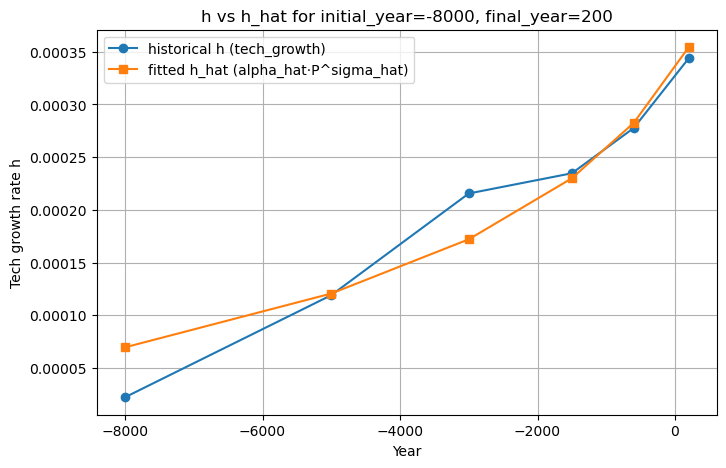

,year,tech_growth,h_hat
0,-8000,0.000022,0.000070
1,-5000,0.000119,0.000121
2,-3000,0.000216,0.000172
3,-1500,0.000235,0.000230
4,-600,0.000278,0.000282
5,200,0.000344,0.000354


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# If you prefer to sample only from "reasonable" rows, you can filter here.
# For now, sample from all rows in alpha_sigma_grid_sorted:
row = alpha_sigma_grid_sorted.sample(1, random_state=None).iloc[0]

iy = int(row["initial_year"])
fy = int(row["final_year"])
alpha_hat = float(row["alpha_hat"])
sigma_hat = float(row["sigma_hat"])

print("Randomly chosen row:")
print(f"  initial_year = {iy}")
print(f"  final_year   = {fy}")
print(f"  alpha_hat    = {alpha_hat:.6g}")
print(f"  sigma_hat    = {sigma_hat:.6g}")

# Build the estimation sample for that window
mask = (
    (human_history_df["year"] >= iy) &
    (human_history_df["year"] <= fy)
)

df_check = human_history_df.loc[
    mask, ["year", "population", "tech_growth"]
].dropna(subset=["population", "tech_growth"]).copy()

df_check = df_check[df_check["population"] > 0].copy()
df_check = df_check.sort_values("year").reset_index(drop=True)

# Compute h_hat using the chosen alpha_hat and sigma_hat
P_vals = df_check["population"].values.astype(float)
df_check["h_hat"] = alpha_hat * np.power(P_vals, sigma_hat)

# Plot historical h vs fitted h_hat
plt.figure(figsize=(8, 5))

plt.plot(df_check["year"], df_check["tech_growth"],
         label="historical h (tech_growth)", marker="o")
plt.plot(df_check["year"], df_check["h_hat"],
         label="fitted h_hat (alpha_hat·P^sigma_hat)", marker="s")

plt.xlabel("Year")
plt.ylabel("Tech growth rate h")
plt.title(f"h vs h_hat for initial_year={iy}, final_year={fy}")
plt.legend()
plt.grid(True)
plt.show()

df_check[["year", "tech_growth", "h_hat"]]
